# Bonusový úkol


In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict
from sklearn.ensemble import RandomForestRegressor
from IPython.display import display

df = pd.read_csv("ToyotaCorolla.csv")
df = df.drop_duplicates().reset_index(drop=True)
df["Mfg_Date"] = pd.to_datetime(dict(year=df["Mfg_Year"], month=df["Mfg_Month"], day=1))
df["Age_Years"] = df["Age_08_04"] / 12
df["Performance_Index"] = df["HP"] / df["Weight"] * 1000
df["Tax_to_Price"] = df["Quarterly_Tax"] / df["Price"]
df["KM_per_Year"] = df["KM"] / df["Age_Years"].replace(0, np.nan)
df["KM_per_Year"] = df["KM_per_Year"].fillna(df["KM_per_Year"].median())
df["Price_per_HP"] = df["Price"] / df["HP"].replace(0, np.nan)
df["Price_per_HP"] = df["Price_per_HP"].fillna(df["Price_per_HP"].median())
df["Price_per_KM"] = df["Price"] / df["KM"].replace(0, np.nan)
df["Price_per_KM"] = df["Price_per_KM"].fillna(df["Price_per_KM"].median())
df["Price_per_KG"] = df["Price"] / df["Weight"]
df["Is_Automatic"] = df["Automatic"].astype(bool)
df["Is_Metallic"] = df["Met_Color"].astype(bool)
df["Doors_Str"] = df["Doors"].astype(str)
df["Fuel_Doors"] = df["Fuel_Type"] + "_" + df["Doors_Str"]
df["YearMonth"] = df["Mfg_Date"].dt.to_period("M").dt.to_timestamp()
df["Age_Band"] = pd.cut(df["Age_08_04"], bins=[0, 12, 18, 24, 30, 36, 60], right=False)
df["KM_Band"] = pd.qcut(df["KM"], 5, duplicates="drop")
df["Weight_Band"] = pd.qcut(df["Weight"], 4, duplicates="drop")
df["HP_Band"] = pd.qcut(df["HP"], 4, duplicates="drop")
flag_cols = ["Mfr_Guarantee","BOVAG_Guarantee","ABS","Airbag_1","Airbag_2","Airco","Automatic_airco","Boardcomputer","CD_Player","Central_Lock","Powered_Windows","Power_Steering","Radio","Mistlamps","Sport_Model","Backseat_Divider","Metallic_Rim","Radio_cassette","Parking_Assistant","Tow_Bar"]
df["Equipment_Count"] = df[flag_cols].sum(axis=1)

gear_stats = df.groupby("Gears")["Price"].agg(["count","mean","median"])
fuel_door_pivot = pd.pivot_table(df, values="Price", index="Fuel_Type", columns="Doors", aggfunc="mean").round(2)
km_age_pivot = pd.pivot_table(df, values="Price", index="KM_Band", columns="Age_Band", aggfunc="mean", observed=False)
color_fuel_pivot = pd.pivot_table(df, values="Price", index="Color", columns="Fuel_Type", aggfunc="mean")
equipment_fuel_pivot = pd.pivot_table(df, values="Price", index="Equipment_Count", columns="Fuel_Type", aggfunc="mean")
year_fuel_pivot = pd.pivot_table(df, values="Price", index="Mfg_Year", columns="Fuel_Type", aggfunc="mean")
year_door_pivot = pd.pivot_table(df, values="Price", index="Mfg_Year", columns="Doors", aggfunc="mean")
time_stats = df.groupby("YearMonth")["Price"].agg(["count","mean","median"]).reset_index()
time_stats["RollingMean"] = time_stats["mean"].rolling(window=3, min_periods=1).mean()
yearly_sum = df.groupby(df['Mfg_Year'])['Price'].sum().reset_index().rename(columns={'Price':'Yearly_Price_Sum'})

month_stats = df.groupby("Mfg_Month")["Price"].agg(["count","mean","median"])
flag_summary = []
for col in flag_cols:
    present = df.loc[df[col]==1,"Price"].mean()
    absent = df.loc[df[col]==0,"Price"].mean()
    diff = present - absent
    flag_summary.append([col,present,absent,diff])

flag_stats_df = pd.DataFrame(flag_summary, columns=["Feature","MeanPriceWithFeature","MeanPriceWithoutFeature","Delta"]).sort_values("Delta", ascending=False)
display(flag_stats_df)


,Feature,MeanPriceWithFeature,MeanPriceWithoutFeature,Delta
6,Automatic_airco,19454.308642,10209.346863,9244.961779
7,Boardcomputer,14104.567376,9322.045410,4782.521966
8,CD_Player,14030.009554,9807.523173,4222.486381
5,Airco,12261.393151,9148.225212,3113.167938
18,Parking_Assistant,13775.000000,10722.321229,3052.678771
2,ABS,11262.510274,8413.626866,2848.883408
10,Powered_Windows,11872.026022,9266.675676,2605.350347
9,Central_Lock,11790.325330,9267.202322,2523.123008
4,Airbag_2,11289.794798,9273.007538,2016.787260
3,Airbag_1,10789.723099,8775.952381,2013.770718


### Analýza vlivu prvků výbavy na průměrnou cenu

Dle dat zobrazených v tabulce jsou pro cenu nejdůležitějšími parametry automatická klimatizace, která u jinak srovnatelných konfigurací dokáže významně zvýšit přeprodejní cenu auta. Dalším prvkem výbavy, který významně přispěl k vyšší ceně vozidel je přítomnost palubního počítače pro sledování a zobrazování základních statistik o provozu auta a také CD přehrávače, které nahradily starší prvek výbavy v podobě kazetových přehrávačů.

Pro mne největším překvapením bylo zjištění, že u aut s tažným zařízením došlo k snížení ceny přeprodávaných vozů. Tato informace však může plynout z podstaty vyššího vytížení automobilů, vyššího opotřebení a rozdílné starostlivosti původních majitelů. Lze totiž předpokládat, že tažné zařízení majitelé konfigurovali a instalovali pro užitkové účely a toto využívání v průběhu let nadměrněji opotřebovávalo auto.


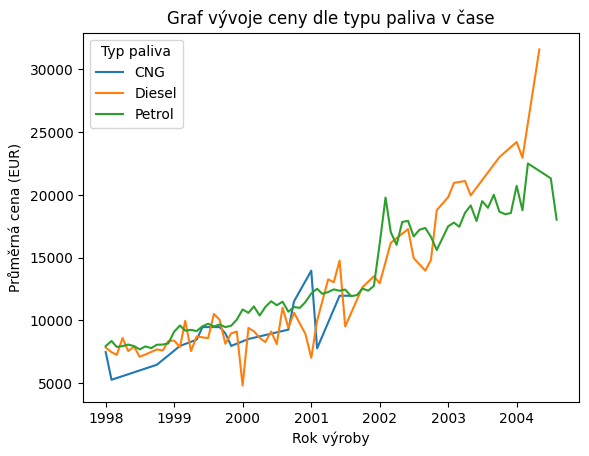

In [2]:
fuel_trend = df.groupby(["YearMonth","Fuel_Type"])["Price"].mean().reset_index()
plt.figure()
sns.lineplot(data=fuel_trend, x="YearMonth", y="Price", hue="Fuel_Type")
plt.title("Graf vývoje ceny dle typu paliva v čase")
plt.xlabel("Rok výroby")
plt.ylabel("Průměrná cena (EUR)")
plt.legend(title="Typ paliva")
plt.show()


### Vývoj průměrné ceny Toyoty Corolly dle typu paliva v čase

Z grafu je jasně parné, že cena vozů s benzínovými i naftovými motory napříč roky byla rovnoměrně rozdělená. Přibližně v roku 2003 vidíme významný nárůst cen naftových verzí na bazarovém trhu. Toto zvýšení ceny lze přiřknout vyšší poptávce zákazníků shodnou s rostoucí popularitou naftových motorů od počátku milénia až po nástup přísnějších norem EURO a kauzy DieselGate, které definitivně ukončily trend rostoucí popularity naftových motorů v osobní dopravě.

V grafu je také zobrazen 3. druhu paliva a to CNG (jež je rozšířením v základu benzínových motorů). Jeho křivka vykazuje vysokou volatilitu, což je pravděpodobně způsobeno malým počtem vozů v různých konfiguracích a také turbulentní historií tohoto paliva, jemuž se dostalo od počátku milénia velké pozornosti a daňových zvýhodnění od vlád napříč EU, protože bylo vnímáno jako palivo budoucnosti ICE vozidel. 

Dataset bohužel nezobrazuje nejdůležitější období a to od roku 2000 do roku 2025, kde by se plně projevil upadající trend naftových motorů na úkor narůstající popularity benzínových motorů a nově hybridních variant automobilu.


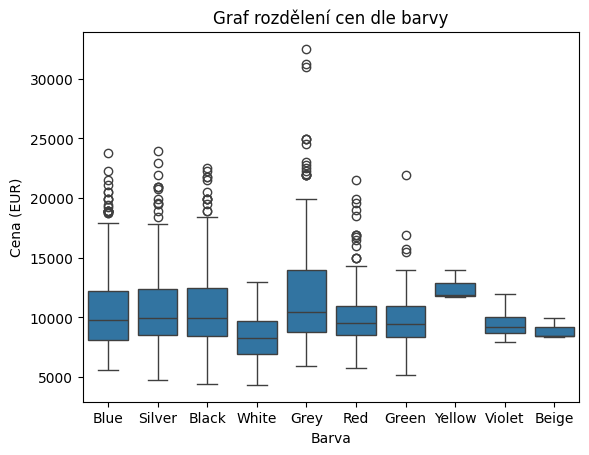

In [3]:
plt.figure()
sns.boxplot(data=df, x="Color", y="Price")
plt.title("Graf rozdělení cen dle barvy")
plt.xlabel("Barva")
plt.ylabel("Cena (EUR)")
plt.show()


### Rozdělení cen Toyoty Corolly dle barvy

Z tohoto grafu jasně vyplývá, že barva automobilu může mít nečekaně velký vliv na jeho přeprodejní cenu. Například černá a červená barva vykazují nejvyšší medián a celkově vyšší tržní hodnotu, což může reflektovat, že tyto barvy byly spojovány s vyššími výbavovými stupni nebo sportovnějšími modely. Naopak barvy jako bílá či béžová mají nejnižší medián a to z důvodu, že jsou spojeny se základními či staršími verzemi.

Ačkoliv parametr barvy není sám o sobě kvalitním parametrem pro predikci ceny, je patrná korelace barvy a ceny auta a to z důvodu vývoje základních barev automobilů a prémiových barev pro vyšší konfigurace. Šedá barva má však viditelně největší cenový rozsah, což je způsobeno její dlouhodobou přítomností jako základní barvy pro všechny verze automobilů a velký počet aut s touto barvou v datasetu v různých konfiguracích.


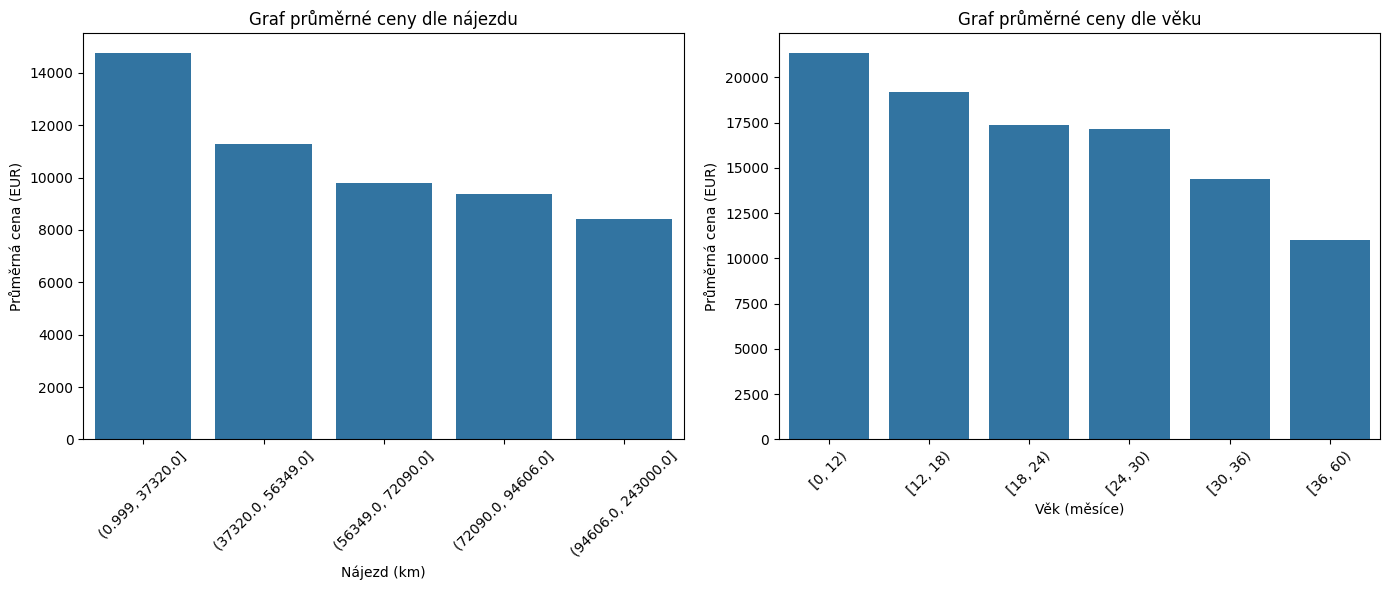

In [4]:
age_stats = df.groupby("Age_Band", observed=False)["Price"].agg(["count","mean","median","min","max"])
age_plot = age_stats.reset_index()
age_plot["Age_Band"] = age_plot["Age_Band"].astype(str)
km_stats = df.groupby("KM_Band", observed=False)["Price"].agg(["count","mean","median"])
km_plot = km_stats.reset_index()
km_plot["KM_Band"] = km_plot["KM_Band"].astype(str)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(data=km_plot, x="KM_Band", y="mean", ax=axes[0])
axes[0].set_title("Graf průměrné ceny dle nájezdu")
axes[0].set_xlabel("Nájezd (km)")
axes[0].set_ylabel("Průměrná cena (EUR)")
axes[0].tick_params(axis="x", rotation=45)
sns.barplot(data=age_plot, x="Age_Band", y="mean", ax=axes[1])
axes[1].set_title("Graf průměrné ceny dle věku")
axes[1].set_xlabel("Věk (měsíce)")
axes[1].set_ylabel("Průměrná cena (EUR)")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


### Průměrná cena dle nájezdu a věku vozidla

Zobrazení těchto dvou srovnávacích grafů jsem zakomponoval pro potvrzení obecně uznávaného pravidla, které říká, že starší vozy a vozy s vyšším nájezdem mají s vyšší pravděpodobností nižší cenu, než jejich srovnatelné verze s lepšími hodnotami. 

V grafu průměrné ceny dle nájezdu je vidět téměř perfektní, plynulý pokles ceny s rostoucími kilometry. Vozidla s nejnižším nájezdem (do 21 tis. km) dosahují průměrné ceny přes 13 000 EUR, zatímco vozy s nejvyšším nájezdem (přes 100 tis. km) klesají k průměru pod 9 000 EUR.

Graf Průměrné ceny dle stáří vozidla vykazuje ještě dramatičtější strmost klesání. Nejnovější vozy (stáří do jednoho roku) mají zdaleka nejvyšší průměrnou cenu a s každou další věkovou skupinou cena prudce klesá. Tyto grafy potvrzují, že věk a nájezd jsou důležitými parametry v cenotvorbě na bazarovém trhu, což odpovídá reálnému chování trhu s ojetými vozy. 

Je však důležité zmínit, že vyšší věk nebo nájezd nutně nemusí znamenat nižší cenu. Vždy záleží na starostlivosti majitelů o vozidlo a konfiguraci vozidla. Teprve kombinace těchto parametrů v kombinaci s nájezdem a stářím vozidla rozhodují o výsledné ceně.


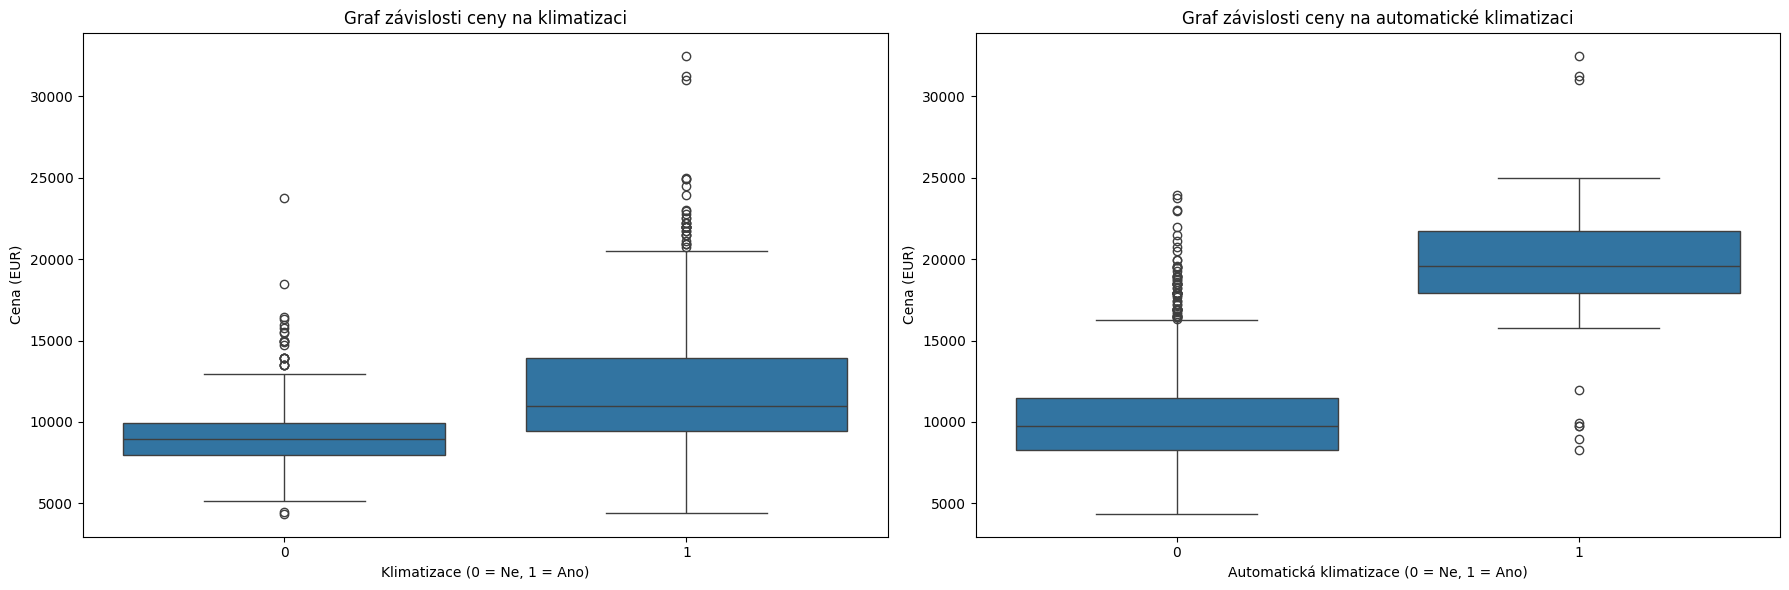

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.boxplot(data=df, x="Airco", y="Price", ax=axes[0])
axes[0].set_title("Graf závislosti ceny na klimatizaci")
axes[0].set_xlabel("Klimatizace (0 = Ne, 1 = Ano)")
axes[0].set_ylabel("Cena (EUR)")
sns.boxplot(data=df, x="Automatic_airco", y="Price", ax=axes[1])
axes[1].set_title("Graf závislosti ceny na automatické klimatizaci")
axes[1].set_xlabel("Automatická klimatizace (0 = Ne, 1 = Ano)")
axes[1].set_ylabel("Cena (EUR)")
plt.tight_layout()
plt.show()


### Rozdělení cen Toyoty Corolly dle typu klimatizace

Jedním z nejdůležitějších parametrů zvažovaných při výběrů nového auta je přítomnost klimatizace a zdali je manuální nebo automatická. U prvního grafu mají sice auta s klimatizací znatelně vyšší medián i celkovou cenovou hladinu než vozy bez ní, ale rozdíl není tak dramatický. 

Velký skok však je u druhého grafu, který zobrazuje rozdíl v ceně mezi auty s manuální klimatizací a klimatizací automatickou. Medián u automatické klimatizace je mnohem výše a celá distribuce je posunuta k vyšším cenám. To dokonale ladí s analýzou z první tabulky a podtrhuje to, že automatická klimatizace je silným ukazatelem prodeje novějších, lépe vybavených a dražších vozů.


Random Forest Model
Mean Absolute Error (MAE): 774.03 EUR
Root Mean Squared Error (RMSE): 1020.77 EUR
R2 Score: 0.92


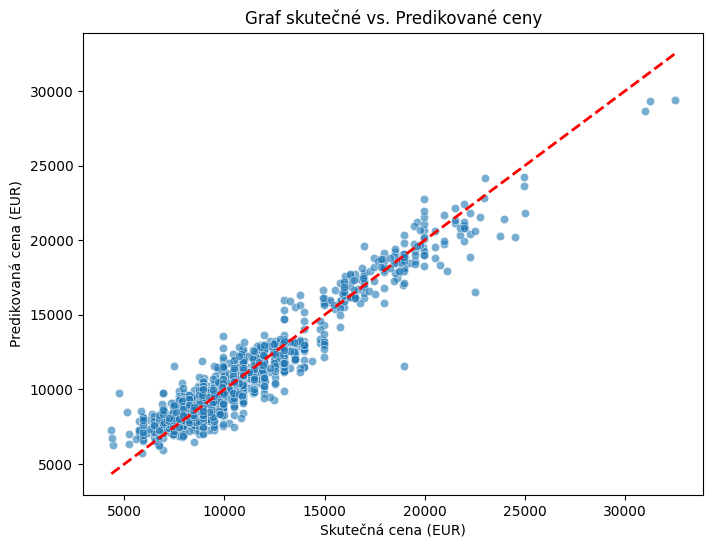


Top 5 parametrů s největším vlivem na cenu:
- Age_Years: 0.3284
- Age_08_04: 0.2679
- Mfg_Year: 0.2299
- Weight: 0.0446
- KM: 0.0289


In [6]:
leakage_cols = ["Price_per_HP", "Tax_to_Price", "Price_per_KM", "Price_per_KG"]
cols_to_drop = ["Id", "Model", "Price", "Mfg_Date", "YearMonth", "Age_Band", "KM_Band", "Weight_Band", "HP_Band", "Doors_Str", "Fuel_Doors"] + leakage_cols

X = df.drop(columns=cols_to_drop)
X = pd.get_dummies(X, columns=["Fuel_Type", "Color"], drop_first=True)
y = df["Price"]

kf = KFold(n_splits=5, shuffle=True, random_state=42)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

mae_scores = -cross_val_score(rf_model, X, y, cv=kf, scoring="neg_mean_absolute_error")
rmse_scores = np.sqrt(-cross_val_score(rf_model, X, y, cv=kf, scoring="neg_mean_squared_error"))
r2_scores = cross_val_score(rf_model, X, y, cv=kf, scoring="r2")

print("Random Forest Model")
print(f"Mean Absolute Error (MAE): {mae_scores.mean():.2f} EUR")
print(f"Root Mean Squared Error (RMSE): {rmse_scores.mean():.2f} EUR")
print(f"R2 Score: {r2_scores.mean():.2f}")

rf_model.fit(X, y)
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top_5_features = feature_importances.nlargest(5)

y_pred_cv = cross_val_predict(rf_model, X, y, cv=kf)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y, y=y_pred_cv, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--", lw=2)
plt.xlabel("Skutečná cena (EUR)")
plt.ylabel("Predikovaná cena (EUR)")
plt.title("Graf skutečné vs. Predikované ceny")
plt.show()

print("\nTop 5 parametrů s největším vlivem na cenu:")
for feature, importance in top_5_features.items():
    print(f"- {feature}: {importance:.4f}")


### Vyhodnocení predikčního modelu Random Forest

R2 skóre dosáhlo hodnoty úžasných 92. Tato hodnota znamená, že daný model je schopen správně, nebo jen s velmi malou odchylkou, predikovat cenu vozu v 92 % případů. V průměru se predikovaná cena od skutečné ceny liší o necelých 800 EUR (MAE = 774,03). V průměrném cenovém relaci 15 000 EUR se jedná o přibližně 5 % odchylku, což osobně považuji za přijatelné.

Výsledky modelu jsou lehce odvoditelné i vizuální kontrolou, kdy jsou téměř všechny modré body nakupeny těsně kolem červené diagonální čáry reprezentující dokonalou predikci. Rozptyl je minimální a díky tomu je model schopný predikovat ceny aut v různých stupních výbavy a s dalšími parametry ovlivňující cenu.

**Top 5 parametrů s největším vlivem na cenu:**

Analýza důležitosti příznaků ukazuje silnou datovou redundanci v čase. Dvě nejdůležitější proměnné, `Age_Years` a `Age_08_04`, jsou si de facto ekvivalentní, a společně s `Mfg_Year` tvoří dominantní trojici, která vysvětluje drtivou většinu (přes 82%) variability ceny.

Závislost váhy vozu na ceně lze poté přiřknout korelaci s vyššími stupni výbavy a vyššími bezpečnostními kritérii, které musely modernější a tedy nověší automobily plnit. V kontextu budoucího vývoje modelu by bylo logické zredukovat tři proměnné spojené se stářím na jednu, aby se zamezilo datové redundanci, aniž by došlo ke ztrátě predikční síly.
